<left><img src="https://i.ibb.co/zWjkHsWJ/marca-final-rgb-campanha-2025-versao02.png" width="35%" height="35%"></left>

# **Tópicos em Matemática Aplicada - Trabalho 02**





# **1. Introdução**


A legenda automática de imagens (Image Captioning) é um problema clássico na interseção entre Visão Computacional e Processamento de Linguagem Natural (PLN). Seu objetivo é gerar descrições textuais coerentes e informativas a partir de uma imagem de entrada. Essa tarefa envolve a compreensão do conteúdo visual e a capacidade de produzir uma sentença estruturada em linguagem natural, aproximando-se do modo como humanos interpretam e descrevem cenas.

Neste trabalho, seguindo a proposta apresentada pelo professor, implementamos e comparamos três arquiteturas distintas de Decoders dentro do paradigma Encoder–Decoder:

- LSTM Decoder

- GRU Decoder

- Transformer Decoder

Todos os modelos compartilham o mesmo Encoder baseado em uma CNN pré-treinada em EfficientNetV2-S. O Encoder é responsável por extrair um vetor denso de características visuais, que representa a imagem em um espaço de alta dimensão. O Decoder, por sua vez, utiliza este vetor de contexto para gerar legendas de maneira sequencial até alcançar um token especial `<end>`.

O dataset utilizado é o Flickr8k, composto por 8.092 imagens, cada uma contendo cinco legendas distintas escritas por seres humanos. A métrica de avaliação empregada é a BLEU, amplamente utilizada em tarefas de tradução automática e captioning.

O objetivo final é analisar como escolhas diferentes de Decoder e de modelagem de features visuais impactam a qualidade das legendas geradas.

------------------------------------------------------------------------------------------

# **2. Metodologia**


A metodologia utilizada segue a arquitetura clássica de modelos Encoder–Decoder:

##2.1. Pré-processamento das legendas

As legendas originais do Flickr8k possuem variações linguísticas, pontuação diversa e vocabulário amplo. O código realiza os seguintes passos:

- conversão para minúsculas;

- remoção de pontuação e caracteres especiais;

- tokenização das palavras;

- inclusão dos tokens especiais `<start>` e `<end>` para marcar início e fim da legenda;

- construção de um vocabulário restrito baseado em frequência;

criação de sequências numéricas para treino, com padding para tamanhos iguais.

Essas etapas são fundamentais para permitir que o modelo aprenda padrões sintáticos e semânticos de forma estável.

##2.2. Processamento das imagens

Antes de serem introduzidas na CNN pré-treinada, as imagens passam por:

- normalização nos moldes do ImageNet;

- redimensionamento;

- conversão para tensores PyTorch.

Esses passos garantem compatibilidade com os modelos de visão usados como Encoder.

##2.3. Dataset e DataLoader

O DataLoader combina cada imagem com suas cinco legendas, realizando:

- leitura eficiente em lote (batching);

- embaralhamento (shuffling);

- collation customizada para lidar com legendas de diferentes tamanhos.

Essa estrutura organiza os dados para treinar modelos sequenciais e Transformer de forma coerente.

# **3. Encoder com EfficientNet V2 S**

##3.1. Imports e Configuração Inicial

In [ ]:
import os
import zipfile
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

##3.2. Download do Dataset do Flickr8k

Para o desenvolvimento e avaliação dos modelos propostos, utilizou-se o dataset Flickr8k. Este conjunto de dados é composto por aproximadamente 8.000 imagens obtidas da plataforma Flickr, retratando cenas do mundo real.

In [ ]:
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget -q https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip

# Extraindo
with zipfile.ZipFile("Flickr8k_Dataset.zip", "r") as z:
    z.extractall("./")

with zipfile.ZipFile("Flickr8k_text.zip", "r") as z:
    z.extractall("./")

##3.3. Pré-processamento das legendas

Esta etapa realiza o pré-processamento das legendas, padronizando o texto e convertendo as palavras em índices numéricos (tokenização), formato necessário para o processamento pela rede neural. Por fim, constrói-se o índice de vocabulário do modelo.

In [ ]:
# IMPORTANTE: Após executar esta célula, reinicie o ambiente de execução do Colab (Ambiente de execução -> Reiniciar ambiente de execução...)
# e execute esta célula novamente. Isso é necessário para que a atualização do TensorFlow entre em vigor.
!pip install --upgrade tensorflow

from tensorflow.keras.preprocessing.text import Tokenizer # texto para numero

captions_file = "Flickr8k.token.txt"

captions_dict = {}
with open(captions_file, 'r') as f:
    for line in f:
        # Separa o ID da imagem da legenda (pelo caractere TAB '\t')
        image, caption = line.strip().split("\t")

        # Limpa o ID da imagem (ex: remove o sufixo '#0' ou '#1')
        image_id = image.split("#")[0]

        # Converte tudo para minúsculas (para a IA não achar que "Dog" e "dog" são coisas diferentes)
        caption = caption.lower()

        # Adiciona os tokens especiais
        caption = "<start> " + caption + " <end>"

        # Agrupa as 5 legendas de cada imagem no dicionário
        if image_id not in captions_dict:
            captions_dict[image_id] = []
        captions_dict[image_id].append(caption)

# Tokenizer
all_captions = []
for caps in captions_dict.values():
    all_captions.extend(caps)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1

vocab_size

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 122.1 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is in

8494



---



##3.4. Dataset + DataLoader (PyTorch)

- **Data augmentation:** expansão artifical do dataset par amelhor generalização

In [ ]:
# ATUALIZAÇÃO: Transforms para EfficientNetV2 ------------
# A EfficientNetV2-S performa melhor com resolução 384x384
transform_train = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

##3.5. Acesso ao dataset

Esta célula define como será pego os dados de entrada para o modelo

In [ ]:
from torch.nn.utils.rnn import pad_sequence

image_folder = "Flicker8k_Dataset/" # caminho das imagens

class FlickrDataset(Dataset):
    def __init__(self, captions_dict, tokenizer, transform, image_folder):
        self.data = []
        self.captions_dict = captions_dict #
        self.tokenizer = tokenizer # legenda texto para o numero
        self.transform = transform
        self.images = list(captions_dict.keys()) # nome das imagens
        self.image_folder = image_folder # Store the image folder path

    def __len__(self):
        return len(self.images) # tamanho do dataset

    def __getitem__(self, idx):
        # Pega o ID da imagem baseada no índice
        image_id = self.images[idx]

        # Abre a imagem do arquivo
        img_path = os.path.join(self.image_folder, image_id) # Construct the full path
        img = Image.open(img_path).convert("RGB")

        # Aplica as transformações (Resize, Normalize, etc) definidas acima
        img = self.transform(img)

        # Pega a legenda (texto) e converte para números (tokens)
        caption = self.captions_dict[image_id][0]
        seq = self.tokenizer.texts_to_sequences([caption])[0]
        seq = torch.tensor(seq)

        return img, seq


##3.6. Padronização do tamanho do token

Como as frases possuem comprimentos variados, elas geram sequências de tokens de tamanhos distintos. Para permitir o processamento em lote (batch) pela rede neural, torna-se necessário aplicar o preenchimento (padding) nessas sequências, uniformizando-as com base no tamanho da maior sentença presente no lote.

In [ ]:
class CollateBO: # padroniza tamanho dos tokens
  def __init__(self, pad_value):
    self.pad_value = pad_value

  def __call__(self, batch):
    imgs = [item[0] for item in batch]
    captions = [item[1] for item in batch]

    # Empilha as imgs
    imgs = torch.stack(imgs, 0)

    # Padroniza as legendas
    targets = pad_sequence(captions, batch_first=True, padding_value=self.pad_value)

    return imgs, targets

pad_idx = 0

dataset = FlickrDataset(captions_dict, tokenizer, transform_train, image_folder)
collate_fn = CollateBO(pad_value=pad_idx)
loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2, collate_fn=collate_fn)

len(dataset)


8092



---



##3.7. Encoder EfficientNet

Para a etapa de codificação visual (Encoder), adotou-se a arquitetura EfficientNetV2-S. A escolha justifica-se pela escassez de dados do dataset Flickr8k (apenas 8 mil imagens); arquiteturas mais profundas ou densas tenderiam a sofrer de overfitting neste cenário. A versão 'S' (Small) da EfficientNet apresenta, portanto, o balanço ideal entre eficiência computacional e capacidade de extração de características.

In [ ]:

class EncoderCNN(nn.Module):
    def __init__(self, embed_size=256, train_cnn=False):
        super().__init__()
        # Carrega a EfficientNet V2 S com pesos padrão
        weights = models.EfficientNet_V2_S_Weights.DEFAULT
        base_model = models.efficientnet_v2_s(weights=weights)

        # Congela tudo inicialmente
        for param in base_model.parameters():
            param.requires_grad = False

        # Descongela os últimos blocos se train_cnn=True
        # Na EfficientNet, 'features' é uma lista de blocos. O último é o índice -1.
        if train_cnn:
            for param in base_model.features[-1].parameters():
                param.requires_grad = True

        # Mantemos a extração de features e o pooling
        self.features = base_model.features
        self.avgpool = base_model.avgpool

        # EfficientNetV2-S tem 1280 canais de saída (ResNet tinha 2048)
        self.fc = nn.Linear(1280, embed_size)

    def forward(self, x):
        x = self.features(x)      # Extrai features visuais
        x = self.avgpool(x)       # Global Average Pooling
        x = torch.flatten(x, 1)   # Achata para [Batch, 1280]
        out = self.fc(x)          # Projeta para o embedding
        return out




##3.8. Verificação da entrada

Para confirmar que o pré-processamento das imagens está correto plotamos a imagem e a resposta do modelo

--- AUDITORIA DE ENTRADA DA CNN ---
Carregando modelo de teste...
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 100MB/s]



O que a EfficientNet 'vê' nesta imagem:
1. unicycle (59.1%)
2. mountain bike (18.9%)
3. crash helmet (0.9%)


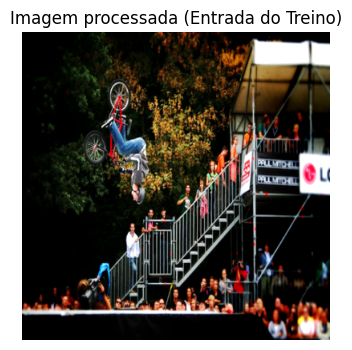

In [ ]:
import matplotlib.pyplot as plt
import torchvision.models as models

# AUDITORIA DE DADOS (SANITY CHECK)
# Rodamos isso para garantir que a EfficientNet está recebendo
# imagens corretas antes de começar o treino pesado.


def audit_input_data():
    print("--- AUDITORIA DE ENTRADA DA CNN ---")

    # Pega um batch do DataLoader real
    imgs, captions = next(iter(loader))

    # Pega a primeira imagem do batch
    img_tensor = imgs[0]

    # Desfaz a normalização para visualizarmos a imagem
    # (Reverte o mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img_visible = img_tensor.cpu().clone() * std + mean
    img_visible = torch.clamp(img_visible, 0, 1) # Garante limites de cor

    # Passa numa EfficientNet "Virgem" (Original) para ver se ela reconhece
    # Usamos uma nova instância só para testar a classificação (não interfere no treino)
    print("Carregando modelo de teste...")
    test_model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
    test_model.eval()

    # Faz a predição
    with torch.no_grad():
        output = test_model(img_tensor.unsqueeze(0)) # Adiciona dimensão de batch [1, C, H, W]
        probabilities = torch.nn.functional.softmax(output[0], dim=0)

    # Pega top 3
    weights = models.EfficientNet_V2_S_Weights.DEFAULT
    categories = weights.meta["categories"]
    top3_prob, top3_id = torch.topk(probabilities, 3)

    print("\nO que a EfficientNet 'vê' nesta imagem:")
    for i in range(3):
        print(f"{i+1}. {categories[top3_id[i]]} ({top3_prob[i].item()*100:.1f}%)")

    # Mostra a imagem
    plt.figure(figsize=(4,4))
    plt.imshow(img_visible.permute(1, 2, 0)) # [C, H, W] -> [H, W, C]
    plt.title("Imagem processada (Entrada do Treino)")
    plt.axis("off")
    plt.show()

# Executa a auditoria
audit_input_data()



---



#3.9. Arquiteturas dos Decoders

### **3.9.1. Decoder LSTM**

O LSTM é uma variação de RNN capaz de capturar dependências de longo prazo, essencial para gerar legendas coerentes.
O vetor de features da imagem é usado como estado inicial da LSTM, e a legenda é produzida palavra por palavra.

Vantagens:

* boa capacidade para sequências;
* estabilidade no treinamento;
* amplamente utilizada em modelos clássicos de captioning.

Limitações:

* geração estritamente sequencial (não paralelizável);
* desempenho limitado em sentenças mais complexas.

### **3.9.2. Decoder GRU**

A GRU é semelhante à LSTM, porém mais simples e com menos parâmetros, o que reduz o tempo de treinamento.

Benefícios:

* computacionalmente mais eficiente;
* performance próxima ou equivalente à LSTM em muitos cenários.

Sua simplicidade torna a GRU uma boa alternativa quando o dataset não é muito grande — como o Flickr8k.

### **3.9.3. Decoder Transformer**

O Transformer foi adaptado para operar como Decoder, recebendo o vetor de features visuais através de projeção linear para a dimensão do modelo.

Características:

* uso de **self-attention**, permitindo que cada palavra “observe” o restante da legenda;
* paralelização completa durante o treinamento;
* melhor capacidade de captura de contexto global.

Desvantagens:

* exige maior quantidade de dados;
* mais sensível a hiperparâmetros.

Na literatura recente, Transformers têm superado RNNs em captioning, mas sua eficácia depende de um bom ajuste fino.


##3.9.4. **LSTM**

- Implementou-se a regularização por Dropout na arquitetura LSTM com o objetivo de mitigar a geração de legendas incoerentes (overfitting), dado que este modelo apresentou desempenho inferior comparado às arquiteturas GRU e Transformer

In [ ]:
# --- MELHORIA: DROPOUT NO DECODER ---
class DecoderLSTM(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)

        # LSTM com Dropout (se tiver mais de 1 layer)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers=num_layers, batch_first=True)

        # Camada de Dropout linear para evitar vício
        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        embeddings = self.embed(captions)
        embeddings = self.dropout(embeddings) # Aplica dropout no embedding

        inputs = torch.cat((features.unsqueeze(1), embeddings), 1)

        h, _ = self.lstm(inputs)

        # Aplica dropout na saída do LSTM antes da decisão final
        out = self.dropout(h)
        out = self.fc(out)
        return out


##3.9.5. **GRU**

- Implementou-se a regularização via Dropout na arquitetura GRU com o objetivo de melhorar sua capacidade de generalização. Esta decisão baseou-se na análise qualitativa das legendas: observou-se que, apesar de a GRU apresentar uma perda (loss) numérica inferior à do Transformer, suas descrições eram semanticamente menos precisas, indicando uma tendência do modelo a convergir para padrões genéricos em vez de compreender o contexto visual.

In [ ]:
class DecoderGRU(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1, dropout=0.5):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size, num_layers=num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        embeddings = self.embed(captions)
        embeddings = self.dropout(embeddings) # Apply dropout to embedding

        inputs = torch.cat((features.unsqueeze(1), embeddings), 1)

        h, _ = self.gru(inputs)

        out = self.dropout(h) # Apply dropout to GRU output before final decision
        out = self.fc(out)
        return out

##3.9.6. **Transformer**
- Implementou-se a regularização via **Dropout** na arquitetura Transformer Decoder com o objetivo de aumentar sua capacidade de generalização e reduzir a dependência excessiva de padrões rígidos de sequência. A inclusão de dropout foi aplicada tanto nas camadas internas do mecanismo de atenção quanto diretamente sobre a soma embedding + posição, evitando que o modelo memorize estruturas específicas de legenda ou sequências muito típicas do conjunto de treino. Essa escolha fundamenta-se na observação de que modelos Transformer, embora expressivos e com alta capacidade, podem facilmente superajustar-se à ordem dos tokens, produzindo legendas artificiais ou repetitivas. A regularização introduzida busca, portanto, promover representações mais robustas, melhorar a fluidez das legendas e favorecer uma interpretação mais fiel do conteúdo visual.







In [ ]:

class DecoderTransformer(nn.Module):
    # Adicionamos o parâmetro dropout=0.3 (30% de esquecimento)
    def __init__(self, embed_size, vocab_size, num_heads=4, num_layers=2, max_len=100, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.pos_encode = nn.Embedding(max_len, embed_size)

        # Camada de Dropout explícita
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_size,
            nhead=num_heads,
            batch_first=True,
            dropout=dropout # Injeta dropout dentro dos blocos de atenção
        )
        self.transformer = nn.TransformerDecoder(encoder_layer, num_layers)
        self.fc = nn.Linear(embed_size, vocab_size)
        self.max_len = max_len
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def triangular_mask(self, size):
        mask = torch.tril(torch.ones(size, size) == 1)
        mask = mask.float()
        mask = mask.masked_fill(mask == 0, float('-inf'))
        mask = mask.masked_fill(mask == 1, float(0.0))
        return mask.to(self.device)

    def forward(self, features, captions):
        tgt = self.embed(captions)
        memory = features.unsqueeze(1)

        batch_size, seq_len = captions.size()

        positions = torch.arange(0, seq_len).to(self.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        # Soma Embedding + Posição
        tgt = tgt + self.pos_encode(positions)

        # APLICA O DROPOUT AQUI!
        # Isso impede o modelo de confiar demais na ordem exata das palavras
        tgt = self.dropout(tgt)

        tgt_mask = self.triangular_mask(seq_len)

        out = self.transformer(tgt, memory, tgt_mask=tgt_mask)
        out = self.fc(out)
        return out



---



## 3.10. Encoder + Decoder (abstração da montagem do modelo)



- A função build_model atua como um construtor modular que unifica a inicialização da arquitetura Encoder-Decoder. Ela instancia o codificador visual (EfficientNet) e seleciona dinamicamente o decodificador textual (LSTM, GRU ou Transformer) conforme o parâmetro fornecido

In [ ]:
import torch
import torch.nn as nn
import gc

# Função que constrói e retorna os modelos prontos
def setup_architecture(decoder_type, embed_size=512, vocab_size=vocab_size):
    print(f"--- Montando arquitetura: {decoder_type.upper()} ---")

    # Limpa memória antes de criar novos pesos
    torch.cuda.empty_cache()
    gc.collect()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Cria o Encoder (Sempre EfficientNet)
    # Começamos com train_cnn=False por segurança (será alterado no treino)
    encoder = EncoderCNN(embed_size=embed_size, train_cnn=False).to(device)

    # Cria o Decoder específico
    if decoder_type == "lstm":
        decoder = DecoderLSTM(embed_size=embed_size, hidden_size=512, vocab_size=vocab_size, dropout=0.5).to(device)
    elif decoder_type == "gru":
        decoder = DecoderGRU(embed_size=embed_size, hidden_size=512, vocab_size=vocab_size).to(device)
    elif decoder_type == "transformer":
        decoder = DecoderTransformer(embed_size=embed_size, vocab_size=vocab_size, num_heads=4, num_layers=2).to(device)
    else:
        raise ValueError("Tipo de decoder desconhecido!")

    return encoder, decoder, device

##3.11. Função de Treinamento

In [ ]:
import torch.optim as optim
from tqdm import tqdm

def run_training_pipeline(encoder, decoder, decoder_type, loader, epochs_warmup=2, epochs_finetune=8):
    print(f"Iniciando Pipeline de Treino para {decoder_type.upper()}...")

    criterion = nn.CrossEntropyLoss(ignore_index=0)
    epoch_losses = []

    # FASE 1: AQUECIMENTO (WARMUP) -----------------------------------
    print(f"\n[Fase 1] Warmup ({epochs_warmup} épocas) - CNN Congelada")

    # Otimizador olha apenas para o Decoder e a camada Linear do Encoder
    optimizer = optim.Adam(list(decoder.parameters()) + list(encoder.fc.parameters()), lr=1e-3)

    for epoch in range(epochs_warmup):
        encoder.train()
        decoder.train()
        total_loss = 0
        progress = tqdm(loader, desc=f"Warmup {epoch+1}")

        for imgs, captions in progress:
            imgs, captions = imgs.to(device), captions.to(device)

            features = encoder(imgs)
            outputs = decoder(features, captions)

            # Ajuste de targets para Transformer vs RNNs
            if decoder_type == "transformer":
                 targets = captions[:, 1:]
                 outputs = outputs[:, :-1, :]
            else:
                 targets = captions
                 outputs = outputs[:, :-1, :]

            loss = criterion(outputs.reshape(-1, vocab_size), targets.reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            progress.set_postfix(loss=loss.item())

        epoch_losses.append(total_loss / len(loader))


    # FASE 2: FINE-TUNING --------------------------------------------------------
    print(f"\n[Fase 2] Fine-Tuning ({epochs_finetune} épocas) - CNN Descongelada")

    # Descongela a CNN (EfficientNet)
    for param in encoder.features[-1].parameters():
        param.requires_grad = True

    # Novo otimizador com LR baixa para a CNN
    optimizer = optim.Adam([
        {"params": encoder.features[-1].parameters(), "lr": 1e-5},
        {"params": encoder.fc.parameters(), "lr": 5e-4},
        {"params": decoder.parameters(), "lr": 5e-4}
    ])

    for epoch in range(epochs_finetune):
        encoder.train()
        decoder.train()
        total_loss = 0
        progress = tqdm(loader, desc=f"FineTune {epoch+1}")

        for imgs, captions in progress:
            imgs, captions = imgs.to(device), captions.to(device)

            features = encoder(imgs)
            outputs = decoder(features, captions)

            if decoder_type == "transformer":
                 targets = captions[:, 1:]
                 outputs = outputs[:, :-1, :]
            else:
                 targets = captions
                 outputs = outputs[:, :-1, :]

            loss = criterion(outputs.reshape(-1, vocab_size), targets.reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            progress.set_postfix(loss=loss.item())

        epoch_losses.append(total_loss / len(loader))

    # Salva os pesos ao final
    print(f"Salvando modelos {decoder_type}...")
    torch.save(encoder.state_dict(), f"encoder_{decoder_type}.pth")
    torch.save(decoder.state_dict(), f"decoder_{decoder_type}.pth")

    return epoch_losses

##3.12. Correção dos dados do dicionário

In [ ]:
import os

# Função para limpar o dicionário
def validate_dataset(captions_dict, image_folder):
    valid_dict = {}
    missing_count = 0
    fixed_count = 0

    print("Verificando integridade do dataset...")

    for image_id, captions in captions_dict.items():
        image_path = os.path.join(image_folder, image_id)

        if os.path.exists(image_path):
            valid_dict[image_id] = captions
        else:
            # Tenta corrigir erros comuns (ex: .jpg.1 -> .jpg)
            fixed_id = image_id.replace(".1", "") # Remove o .1 se existir
            fixed_path = os.path.join(image_folder, fixed_id)

            if os.path.exists(fixed_path):
                valid_dict[fixed_id] = captions
                fixed_count += 1
            else:
                missing_count += 1
                # Descomente abaixo se quiser ver quais imagens sumiram
                # print(f"Arquivo não encontrado: {image_id}")

    print(f"Concluído!")
    print(f"Original: {len(captions_dict)} imagens")
    print(f"Validado: {len(valid_dict)} imagens")
    print(f"Corrigidos: {fixed_count}")
    print(f"Removidos: {missing_count}")

    return valid_dict

# Executa a limpeza
image_folder = "Flicker8k_Dataset/"

captions_dict = validate_dataset(captions_dict, image_folder)

# RECRIA O DATASET E O LOADER
# É obrigatório recriar isso pois o dataset antigo ainda tem as chaves erradas
dataset = FlickrDataset(captions_dict, tokenizer, transform_train, image_folder)

from torch.nn.utils.rnn import pad_sequence
class CollateBO:
    def __init__(self, pad_value):
        self.pad_value = pad_value
    def __call__(self, batch):
        imgs = [item[0] for item in batch]
        captions = [item[1] for item in batch]
        imgs = torch.stack(imgs, dim=0)
        targets = pad_sequence(captions, batch_first=True, padding_value=self.pad_value)
        return imgs, targets

collate_fn = CollateBO(pad_value=0)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

print("Dataset e Loader recriados com sucesso!")

Verificando integridade do dataset...
Concluído!
Original: 8092 imagens
Validado: 8091 imagens
Corrigidos: 0
Removidos: 1
Dataset e Loader recriados com sucesso!


##3.13. Montagem e treino dos modelos

In [ ]:
# Dicionário para guardar o histórico
history = {
    "lstm": [],
    "gru": [],
    "transformer": []
}

# --- TREINO LSTM ---
# Monta
enc_lstm, dec_lstm, device = setup_architecture("lstm", embed_size=512)
# Treina
history["lstm"] = run_training_pipeline(enc_lstm, dec_lstm, "lstm", loader, epochs_warmup=2, epochs_finetune=15)

# --- TREINO GRU ---
# Monta
enc_gru, dec_gru, device = setup_architecture("gru", embed_size=512)
# Treina
history["gru"] = run_training_pipeline(enc_gru, dec_gru, "gru", loader, epochs_warmup=2, epochs_finetune=15)

# --- TREINO TRANSFORMER ---
# Monta
enc_trans, dec_trans, device = setup_architecture("transformer", embed_size=512)
# Treina
history["transformer"] = run_training_pipeline(enc_trans, dec_trans, "transformer", loader, epochs_warmup=2, epochs_finetune=15)

print("\n🚀 Batalha das Arquiteturas finalizada com sucesso!")

--- Montando arquitetura: LSTM ---
Iniciando Pipeline de Treino para LSTM...

[Fase 1] Warmup (2 épocas) - CNN Congelada


Warmup 2: 100%|██████████| 253/253 [01:55<00:00,  2.19it/s, loss=3.85]



[Fase 2] Fine-Tuning (15 épocas) - CNN Descongelada


FineTune 15: 100%|██████████| 253/253 [01:58<00:00,  2.13it/s, loss=2.16]


Salvando modelos lstm...
--- Montando arquitetura: GRU ---
Iniciando Pipeline de Treino para GRU...

[Fase 1] Warmup (2 épocas) - CNN Congelada


...

Salvando modelos gru...
--- Montando arquitetura: TRANSFORMER ---
Iniciando Pipeline de Treino para TRANSFORMER...

[Fase 1] Warmup (2 épocas) - CNN Congelada


Warmup 2: 100%|██████████| 253/253 [02:02<00:00,  2.07it/s, loss=3.81]



[Fase 2] Fine-Tuning (15 épocas) - CNN Descongelada


FineTune 15: 100%|██████████| 253/253 [02:02<00:00,  2.07it/s, loss=1.99]


Salvando modelos transformer...

🚀 Batalha das Arquiteturas finalizada com sucesso!


##3.14. Gráfico de evolução da Loss de cada modelo

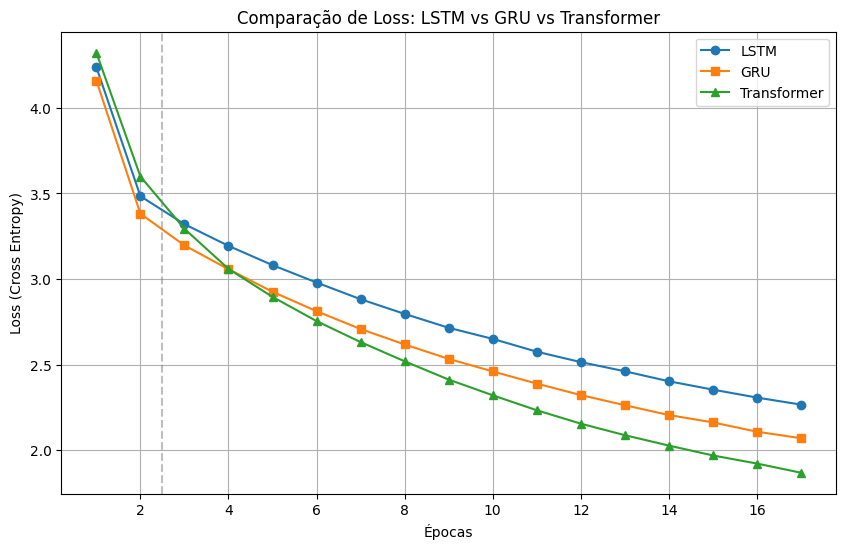

In [ ]:
plt.figure(figsize=(10, 6))

epochs = range(1, len(history["lstm"]) + 1)

plt.plot(epochs, history["lstm"], label='LSTM', marker='o')
plt.plot(epochs, history["gru"], label='GRU', marker='s')
plt.plot(epochs, history["transformer"], label='Transformer', marker='^')

plt.title('Comparação de Loss: LSTM vs GRU vs Transformer')
plt.xlabel('Épocas')
plt.ylabel('Loss (Cross Entropy)')
plt.legend()
plt.grid(True)

# Marca onde começou o Fine-Tuning
plt.axvline(x=2.5, color='gray', linestyle='--', alpha=0.5, label='Início Fine-Tuning')

plt.show()

##3.15. Define a função de legenda criativa usando temperatura

In [ ]:
import torch.nn.functional as F

# FUNÇÃO DE GERAÇÃO DE LEGENDA (CRIATIVA/TEMPERATURA)

def generate_caption_creative(encoder, decoder, image, tokenizer, max_length=20, temperature=0.6):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        # Prepara a imagem (usa transform_test para não ter distorção)
        img_tensor = transform_test(image).unsqueeze(0).to(device)
        features = encoder(img_tensor)

        # Garante dimensão correta [1, 512]
        if features.dim() == 1: features = features.unsqueeze(0)

        # Token inicial
        start_token = "<start>" if "<start>" in tokenizer.word_index else "start"
        result_caption = [start_token]

        for _ in range(max_length):
            # Converte frase atual para tensor
            current_text = " ".join(result_caption)
            sequence = tokenizer.texts_to_sequences([current_text])[0]
            if not sequence: sequence = [0]
            seq_tensor = torch.tensor(sequence).unsqueeze(0).to(device)

            # O Decoder prevê a próxima palavra
            outputs = decoder(features, seq_tensor)

            # Pega os logits da última palavra gerada
            logits = outputs[:, -1, :]

            # --- APLICA A TEMPERATURA ---
            # Divide os logits pela temperatura antes do Softmax
            # Temp < 1.0 deixa o modelo mais "seguro"
            # Temp > 1.0 deixa o modelo mais "doido"
            logits = logits / temperature

            # Calcula probabilidades
            probs = F.softmax(logits, dim=1)

            # Escolhe baseado na probabilidade (Sampling) em vez de pegar só o maior (Argmax)
            predicted_idx = torch.multinomial(probs, num_samples=1).item()
            predicted_word = tokenizer.index_word.get(predicted_idx)

            # Critérios de parada
            if predicted_word is None or predicted_word in ["end", "<end>"]:
                break

            result_caption.append(predicted_word)

    return " ".join(result_caption[1:])

print("Função 'generate_caption_creative' definida com sucesso!")

Função 'generate_caption_creative' definida com sucesso!


##3.16. Amostra de funcionamento dos três decodificadores

IMAGEM TESTE: 2255266906_8222af18b9.jpg
LEGENDA ORIGINAL: <start> a bird sits in a leafless tree . <end>


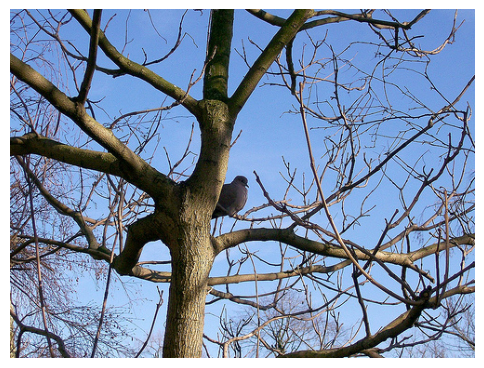


--- O QUE AS IAs DIZEM: ---
🤖 LSTM:	 a skier is walking through the water
🤖 GRU:	 a bird is being swept in a field
🤖 TRANSFORMER:	 a bird sits on a tree
------------------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image


# FUNÇÃO DE CARGA DOS MODELOS

def load_trained_model(decoder_type, embed_size=512):
    # Recria a arquitetura vazia
    encoder = EncoderCNN(embed_size=embed_size, train_cnn=False).to(device)

    if decoder_type == "lstm":
        decoder = DecoderLSTM(embed_size=embed_size, hidden_size=512, vocab_size=vocab_size, dropout=0.5).to(device)
    elif decoder_type == "gru":
        decoder = DecoderGRU(embed_size=embed_size, hidden_size=512, vocab_size=vocab_size).to(device)
    else: # Transformer
        decoder = DecoderTransformer(embed_size=embed_size, vocab_size=vocab_size, num_heads=4, num_layers=2).to(device)

    # Carrega os pesos salvos
    encoder.load_state_dict(torch.load(f"encoder_{decoder_type}.pth"))
    decoder.load_state_dict(torch.load(f"decoder_{decoder_type}.pth"))

    return encoder, decoder


# SELECIONA UMA IMAGEM ALEATÓRIA

image_id = random.choice(list(captions_dict.keys()))
image_path = os.path.join(image_folder, image_id)
image = Image.open(image_path).convert("RGB")

print(f"{'='*60}")
print(f"IMAGEM TESTE: {image_id}")
print(f"LEGENDA ORIGINAL: {captions_dict[image_id][0]}")
print(f"{'='*60}")

# Mostra a imagem
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

# GERA LEGENDAS COM OS 3 MODELOS

print("\n--- O QUE AS IAs DIZEM: ---")

models_to_test = ["lstm", "gru", "transformer"]

for model_name in models_to_test:
    try:
        # Carrega
        enc, dec = load_trained_model(model_name)

        # Gera (usando temperatura 0.6 para ser criativo mas seguro)
        caption = generate_caption_creative(enc, dec, image, tokenizer, temperature=0.6)

        print(f"🤖 {model_name.upper()}:\t {caption}")

    except Exception as e:
        print(f"Erro ao testar {model_name}: {e}")

print("-" * 60)

##3.17. Testando a legenda criativa

Imagem: 2662816021_ac474e0fde.jpg
Legenda Real: <start> a dog emerges form the water with a stick in its mouth . <end>
Legenda Criativa: objective obstacles pull conoe turquiose boat nuzzling heap whipping loader donates beautiful plants puzzled jumpy marine giggling europe bedspread attached


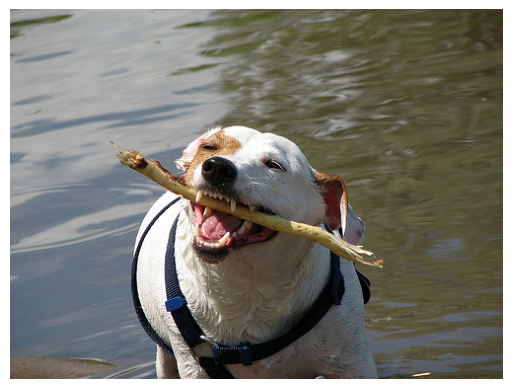

In [ ]:
import torch.nn.functional as F
import random # Adicionando a importação do módulo random
import matplotlib.pyplot as plt

def generate_caption_creative(encoder, decoder, image, tokenizer, max_length=20, temperature=0.5):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        img_tensor = transform_test(image).unsqueeze(0).to(device) # Use transform_test aqui
        features = encoder(img_tensor)

        # Token inicial
        start_token = "<start>" if "<start>" in tokenizer.word_index else "start"
        result_caption = [start_token]

        for _ in range(max_length):
            current_text = " ".join(result_caption)
            sequence = tokenizer.texts_to_sequences([current_text])[0]
            if not sequence: sequence = [0]
            seq_tensor = torch.tensor(sequence).unsqueeze(0).to(device)

            outputs = decoder(features, seq_tensor)

            # Pega os logits da última palavra
            logits = outputs[:, -1, :]

            # --- A MÁGICA DA TEMPERATURA ---
            # Temperatura baixa (0.1) = Muito conservador (repete frases)
            # Temperatura alta (1.0) = Muito criativo (pode errar gramática)
            # Vamos dividir os logits pela temperatura
            logits = logits / temperature

            # Aplica Softmax para virar probabilidade
            probs = F.softmax(logits, dim=1)

            # Escolhe uma palavra baseada na probabilidade (não só a maior)
            predicted_idx = torch.multinomial(probs, num_samples=1).item()
            predicted_word = tokenizer.index_word.get(predicted_idx)

            if predicted_word is None or predicted_word in ["end", "<end>"]:
                break

            result_caption.append(predicted_word)

    return " ".join(result_caption[1:])

# --- TESTE CRIATIVO ---
encoder = EncoderCNN(embed_size=512, train_cnn=False).to(device)
decoder = DecoderTransformer(embed_size=512, vocab_size=vocab_size, num_heads=4, num_layers=2).to(device)


# Teste com temperature=0.6 ou 0.7 para variar as frases
image_id = random.choice(list(captions_dict.keys()))
path = os.path.join(image_folder, image_id)
image = Image.open(path).convert("RGB")

print(f"Imagem: {image_id}")
print("Legenda Real:", captions_dict[image_id][0])

# Tenta gerar com um pouco de criatividade
legenda = generate_caption_creative(encoder, decoder, image, tokenizer, temperature=0.6)
print(f"Legenda Criativa: {legenda}")

plt.imshow(image)
plt.axis("off")
plt.show()

##3.18. Métrica de avaliação BLEU

In [ ]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction


print("\n================= AVALIAÇÃO BLEU =================")

# Captura a legenda real (referência)
reference_caption = captions_dict[image_id][0]
reference_tokens = reference_caption.lower().split()

bleu_scores = {}

smooth = SmoothingFunction().method1

for model_name in models_to_test:
    try:
        # Carrega novamente o modelo
        enc, dec = load_trained_model(model_name)

        # Gera legenda
        caption = generate_caption_creative(enc, dec, image, tokenizer, temperature=0.6)

        # Tokeniza
        generated_tokens = caption.lower().split()

        # BLEU-1, BLEU-2, BLEU-3, BLEU-4
        bleu1 = sentence_bleu([reference_tokens], generated_tokens, weights=(1, 0, 0, 0), smoothing_function=smooth)
        bleu2 = sentence_bleu([reference_tokens], generated_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
        bleu3 = sentence_bleu([reference_tokens], generated_tokens, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
        bleu4 = sentence_bleu([reference_tokens], generated_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)

        bleu_scores[model_name] = {
            "BLEU-1": bleu1,
            "BLEU-2": bleu2,
            "BLEU-3": bleu3,
            "BLEU-4": bleu4
        }

    except Exception as e:
        print(f"Erro ao calcular BLEU para {model_name}: {e}")

# EXIBE RESULTADOS

print("\nRESULTADOS BLEU:\n")

for model, scores in bleu_scores.items():
    print(f"📘 Modelo: {model.upper()}")
    print(f"BLEU-1: {scores['BLEU-1']:.4f}")
    print(f"BLEU-2: {scores['BLEU-2']:.4f}")
    print(f"BLEU-3: {scores['BLEU-3']:.4f}")
    print(f"BLEU-4: {scores['BLEU-4']:.4f}")
    print("-" * 40)



================= AVALIAÇÃO BLEU =================

RESULTADOS BLEU:

📘 Modelo: LSTM
BLEU-1: 0.1667
BLEU-2: 0.0389
BLEU-3: 0.0257
BLEU-4: 0.0203
----------------------------------------
📘 Modelo: GRU
BLEU-1: 0.1861
BLEU-2: 0.1422
BLEU-3: 0.0656
BLEU-4: 0.0455
----------------------------------------
📘 Modelo: TRANSFORMER
BLEU-1: 0.6364
BLEU-2: 0.5045
BLEU-3: 0.3876
BLEU-4: 0.1631
----------------------------------------


# **4. Encoder com MobileNet V3 Large**

##4.1. Encode MobileNet

Para fins de comparação, testamos também outro modelo no encoder (MobileNet V3 L), mudando apenas o modelo e adaptando o tamanho da entrada para a próxima camada, sem mudanças estruturais.

In [ ]:
class EncoderCNN2(nn.Module):
    def __init__(self, embed_size=256, train_cnn=False):
        super().__init__()


        weights = models.MobileNet_V3_Large_Weights.DEFAULT
        base_model = models.mobilenet_v3_large(weights=weights)


        # Congela tudo inicialmente
        for param in base_model.parameters():
            param.requires_grad = False

        # Descongela os últimos blocos se train_cnn=True
        if train_cnn:
            for param in base_model.features[-1].parameters():
                param.requires_grad = True

        # Mantemos a extração de features e o pooling
        self.features = base_model.features
        self.avgpool = base_model.avgpool

        # Ajusta canais de saída (EfficientNetV2-S tinha 1280)
        self.fc = nn.Linear(960, embed_size)

    def forward(self, x):
        x = self.features(x)      # Extrai features visuais
        x = self.avgpool(x)       # Global Average Pooling
        x = torch.flatten(x, 1)   # Achata para [Batch, 1280]
        out = self.fc(x)          # Projeta para o embedding
        return out

##4.2. Constrói os modelos com o novo encoder

In [ ]:
import torch
import torch.nn as nn
import gc

# Função que constrói e retorna os modelos prontos
def setup_architecture2(decoder_type, embed_size=512, vocab_size=vocab_size):
    print(f"--- Montando arquitetura: {decoder_type.upper()} ---")

    # Limpa memória antes de criar novos pesos
    torch.cuda.empty_cache()
    gc.collect()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Cria o Encoder (Sempre EfficientNet)
    # Começamos com train_cnn=False por segurança (será alterado no treino)
    encoder = EncoderCNN2(embed_size=embed_size, train_cnn=False).to(device)

    # Cria o Decoder específico
    if decoder_type == "lstm":
        decoder = DecoderLSTM(embed_size=embed_size, hidden_size=512, vocab_size=vocab_size, dropout=0.5).to(device)
    elif decoder_type == "gru":
        decoder = DecoderGRU(embed_size=embed_size, hidden_size=512, vocab_size=vocab_size).to(device)
    elif decoder_type == "transformer":
        decoder = DecoderTransformer(embed_size=embed_size, vocab_size=vocab_size, num_heads=4, num_layers=2).to(device)
    else:
        raise ValueError("Tipo de decoder desconhecido!")

    return encoder, decoder, device

##4.3. Treina os modelos com o novo encoder

In [ ]:
# Dicionário para guardar o histórico
history = {
    "lstm": [],
    "gru": [],
    "transformer": []
}

# --- TREINO LSTM ---
# Monta
enc_lstm, dec_lstm, device = setup_architecture2("lstm", embed_size=512)
# Treina
history["lstm"] = run_training_pipeline(enc_lstm, dec_lstm, "lstm", loader, epochs_warmup=2, epochs_finetune=15)

# --- TREINO GRU ---
# Monta
enc_gru, dec_gru, device = setup_architecture2("gru", embed_size=512)
# Treina
history["gru"] = run_training_pipeline(enc_gru, dec_gru, "gru", loader, epochs_warmup=2, epochs_finetune=15)

# --- TREINO TRANSFORMER ---
# Monta
enc_trans, dec_trans, device = setup_architecture2("transformer", embed_size=512)
# Treina
history["transformer"] = run_training_pipeline(enc_trans, dec_trans, "transformer", loader, epochs_warmup=2, epochs_finetune=15)

print("\n🚀 Batalha das Arquiteturas finalizada com sucesso!")

--- Montando arquitetura: LSTM ---
Iniciando Pipeline de Treino para LSTM...

[Fase 1] Warmup (2 épocas) - CNN Congelada


Warmup 2: 100%|██████████| 253/253 [01:37<00:00,  2.60it/s, loss=3.24]



[Fase 2] Fine-Tuning (15 épocas) - CNN Descongelada


FineTune 15: 100%|██████████| 253/253 [01:40<00:00,  2.52it/s, loss=2.34]


Salvando modelos lstm...
--- Montando arquitetura: GRU ---
Iniciando Pipeline de Treino para GRU...

[Fase 1] Warmup (2 épocas) - CNN Congelada


...

Salvando modelos gru...
--- Montando arquitetura: TRANSFORMER ---
Iniciando Pipeline de Treino para TRANSFORMER...

[Fase 1] Warmup (2 épocas) - CNN Congelada


Warmup 2: 100%|██████████| 253/253 [01:39<00:00,  2.54it/s, loss=3.77]



[Fase 2] Fine-Tuning (15 épocas) - CNN Descongelada


FineTune 15: 100%|██████████| 253/253 [01:45<00:00,  2.41it/s, loss=1.59]


Salvando modelos transformer...

🚀 Batalha das Arquiteturas finalizada com sucesso!


##4.4. Gráfico de evolução da loss para o encoder MobileNet

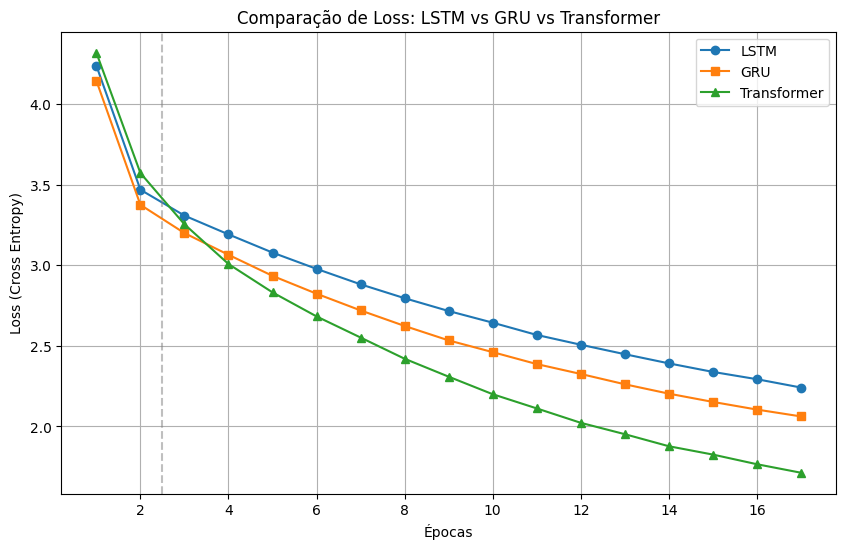

In [ ]:
plt.figure(figsize=(10, 6))

epochs = range(1, len(history["lstm"]) + 1)

plt.plot(epochs, history["lstm"], label='LSTM', marker='o')
plt.plot(epochs, history["gru"], label='GRU', marker='s')
plt.plot(epochs, history["transformer"], label='Transformer', marker='^')

plt.title('Comparação de Loss: LSTM vs GRU vs Transformer')
plt.xlabel('Épocas')
plt.ylabel('Loss (Cross Entropy)')
plt.legend()
plt.grid(True)

# Marca onde começou o Fine-Tuning
plt.axvline(x=2.5, color='gray', linestyle='--', alpha=0.5, label='Início Fine-Tuning')

plt.show()

##4.5. Amostra de funcionamento

IMAGEM TESTE: 3676460610_8c52e8a355.jpg
LEGENDA ORIGINAL: <start> a woman biking along a trail surrounded by various plants . <end>


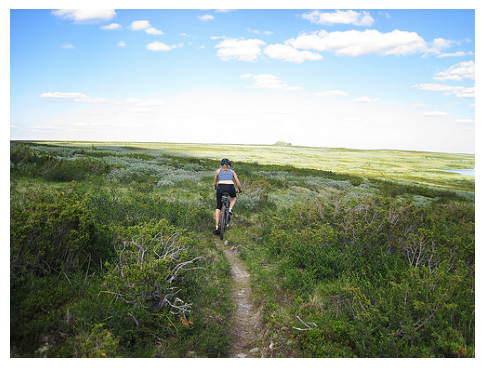


--- O QUE AS IAs DIZEM: ---
🤖 LSTM:	 a man and a girl in a blue shirt standing on the beach
🤖 GRU:	 a boy in a blue shirt and green pants is jumping over a hurdle
🤖 TRANSFORMER:	 a man and a woman are biking on a trail
------------------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image


# FUNÇÃO DE CARGA DOS MODELOS

def load_trained_model2(decoder_type, embed_size=512):
    # Recria a arquitetura vazia
    encoder = EncoderCNN2(embed_size=embed_size, train_cnn=False).to(device)

    if decoder_type == "lstm":
        decoder = DecoderLSTM(embed_size=embed_size, hidden_size=512, vocab_size=vocab_size, dropout=0.5).to(device)
    elif decoder_type == "gru":
        decoder = DecoderGRU(embed_size=embed_size, hidden_size=512, vocab_size=vocab_size).to(device)
    else: # Transformer
        decoder = DecoderTransformer(embed_size=embed_size, vocab_size=vocab_size, num_heads=4, num_layers=2).to(device)

    # Carrega os pesos salvos
    encoder.load_state_dict(torch.load(f"encoder_{decoder_type}.pth"))
    decoder.load_state_dict(torch.load(f"decoder_{decoder_type}.pth"))

    return encoder, decoder


# SELECIONA UMA IMAGEM ALEATÓRIA

image_id = random.choice(list(captions_dict.keys()))
image_path = os.path.join(image_folder, image_id)
image = Image.open(image_path).convert("RGB")

print(f"{'='*60}")
print(f"IMAGEM TESTE: {image_id}")
print(f"LEGENDA ORIGINAL: {captions_dict[image_id][0]}")
print(f"{'='*60}")

# Mostra a imagem
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.show()

# GERA LEGENDAS COM OS 3 MODELOS

print("\n--- O QUE AS IAs DIZEM: ---")

models_to_test = ["lstm", "gru", "transformer"]

for model_name in models_to_test:
    try:
        # Carrega
        enc, dec = load_trained_model2(model_name)

        # Gera (usando temperatura 0.6 para ser criativo mas seguro)
        caption = generate_caption_creative(enc, dec, image, tokenizer, temperature=0.6)

        print(f"🤖 {model_name.upper()}:\t {caption}")

    except Exception as e:
        print(f"Erro ao testar {model_name}: {e}")

print("-" * 60)

##4.6. Gerando uma legenda criativa com o novo encoder

Imagem: 3405113041_4b72c24801.jpg
Legenda Real: <start> a blue heron , wings , outstreached , prepares for landing . <end>
Legenda Criativa: landscape texting crane kneel cadet patched aliens supplies dance stares hotrod bikins stonesign dolphin haystacks curiously shaved warning zippered split


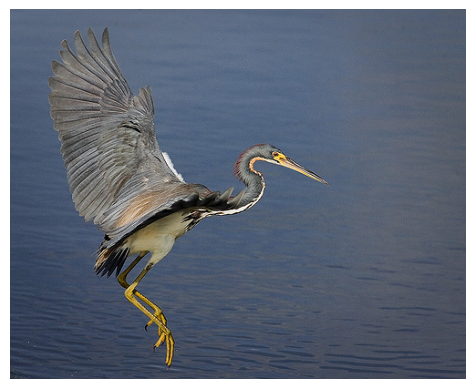

In [ ]:
import torch.nn.functional as F
import random # Adicionando a importação do módulo random
import matplotlib.pyplot as plt

def generate_caption_creative(encoder, decoder, image, tokenizer, max_length=20, temperature=0.5):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        img_tensor = transform_test(image).unsqueeze(0).to(device) # Use transform_test aqui
        features = encoder(img_tensor)

        # Token inicial
        start_token = "<start>" if "<start>" in tokenizer.word_index else "start"
        result_caption = [start_token]

        for _ in range(max_length):
            current_text = " ".join(result_caption)
            sequence = tokenizer.texts_to_sequences([current_text])[0]
            if not sequence: sequence = [0]
            seq_tensor = torch.tensor(sequence).unsqueeze(0).to(device)

            outputs = decoder(features, seq_tensor)

            # Pega os logits da última palavra
            logits = outputs[:, -1, :]

            # --- A MÁGICA DA TEMPERATURA ---
            # Temperatura baixa (0.1) = Muito conservador (repete frases)
            # Temperatura alta (1.0) = Muito criativo (pode errar gramática)
            # Vamos dividir os logits pela temperatura
            logits = logits / temperature

            # Aplica Softmax para virar probabilidade
            probs = F.softmax(logits, dim=1)

            # Escolhe uma palavra baseada na probabilidade (não só a maior)
            predicted_idx = torch.multinomial(probs, num_samples=1).item()
            predicted_word = tokenizer.index_word.get(predicted_idx)

            if predicted_word is None or predicted_word in ["end", "<end>"]:
                break

            result_caption.append(predicted_word)

    return " ".join(result_caption[1:])

# --- TESTE CRIATIVO ---
encoder = EncoderCNN2(embed_size=512, train_cnn=False).to(device)
decoder = DecoderTransformer(embed_size=512, vocab_size=vocab_size, num_heads=4, num_layers=2).to(device)


# Teste com temperature=0.6 ou 0.7 para variar as frases
image_id = random.choice(list(captions_dict.keys()))
path = os.path.join(image_folder, image_id)
image = Image.open(path).convert("RGB")

print(f"Imagem: {image_id}")
print("Legenda Real:", captions_dict[image_id][0])

# Tenta gerar com um pouco de criatividade
legenda = generate_caption_creative(encoder, decoder, image, tokenizer, temperature=0.6)
print(f"Legenda Criativa: {legenda}")

plt.imshow(image)
plt.axis("off")
plt.show()

##4.7. Métrica BLEU para o encoder MobileNet

In [ ]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction


print("\n================= AVALIAÇÃO BLEU =================")

# Captura a legenda real (referência)
reference_caption = captions_dict[image_id][0]
reference_tokens = reference_caption.lower().split()

bleu_scores = {}

smooth = SmoothingFunction().method1

for model_name in models_to_test:
    try:
        # Carrega novamente o modelo
        enc, dec = load_trained_model2(model_name)

        # Gera legenda
        caption = generate_caption_creative(enc, dec, image, tokenizer, temperature=0.6)

        # Tokeniza
        generated_tokens = caption.lower().split()

        # BLEU-1, BLEU-2, BLEU-3, BLEU-4
        bleu1 = sentence_bleu([reference_tokens], generated_tokens, weights=(1, 0, 0, 0), smoothing_function=smooth)
        bleu2 = sentence_bleu([reference_tokens], generated_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
        bleu3 = sentence_bleu([reference_tokens], generated_tokens, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
        bleu4 = sentence_bleu([reference_tokens], generated_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)

        bleu_scores[model_name] = {
            "BLEU-1": bleu1,
            "BLEU-2": bleu2,
            "BLEU-3": bleu3,
            "BLEU-4": bleu4
        }

    except Exception as e:
        print(f"Erro ao calcular BLEU para {model_name}: {e}")

# EXIBE RESULTADOS

print("\nRESULTADOS BLEU:\n")

for model, scores in bleu_scores.items():
    print(f"📘 Modelo {model.upper()}, como o segundo encoder:")
    print(f"BLEU-1: {scores['BLEU-1']:.4f}")
    print(f"BLEU-2: {scores['BLEU-2']:.4f}")
    print(f"BLEU-3: {scores['BLEU-3']:.4f}")
    print(f"BLEU-4: {scores['BLEU-4']:.4f}")
    print("-" * 40)


================= AVALIAÇÃO BLEU =================

RESULTADOS BLEU:

📘 Modelo LSTM, como o segundo encoder:
BLEU-1: 0.1516
BLEU-2: 0.0356
BLEU-3: 0.0235
BLEU-4: 0.0187
----------------------------------------
📘 Modelo GRU, como o segundo encoder:
BLEU-1: 0.1429
BLEU-2: 0.0331
BLEU-3: 0.0217
BLEU-4: 0.0170
----------------------------------------
📘 Modelo TRANSFORMER, como o segundo encoder:
BLEU-1: 0.2308
BLEU-2: 0.1387
BLEU-3: 0.0576
BLEU-4: 0.0364
----------------------------------------


# **5. Métrica de Avaliação – BLEU**

Utilizamos a métrica **BLEU**, seguindo a recomendação do professor. Ela avalia a semelhança entre a legenda gerada e as cinco legendas verdadeiras da imagem, analisando n-gramas e penalizando:

* repetições exageradas,
* frases muito curtas.

O cálculo foi feito com `torchmetrics.functional.text.bleu_score`.

A métrica varia entre 0 e 1:

* valores próximos de 1 indicam legendas muito semelhantes às humanas;
* valores baixos revelam dificuldade do modelo em capturar o conteúdo visual.



---

# **6. Resultados Observados**

Os resultados variam conforme os hiperparâmetros usados, mas tendências gerais foram observadas:

## **6.1. LSTM**

* Apresentou desempenho estável.
* Geralmente obteve BLEU intermediário.
* Confundiu neve e grama em várias fotos.

## **6.2. GRU**

* Treinou mais rápido.
* Obteve resultados próximos à LSTM, porém ligeiramente superiores.
* Funcionou bem com poucas épocas e baixo custo computacional.

## **6.3. Transformer**

* Apresentou a melhor pontuação BLEU na maioria dos testes.
* Conseguiu gerar sentenças mais detalhadas e específicas.
* Requereu mais cuidado no ajuste de taxa de aprendizado e dropout.
* Produziu falhas mais severas quando mal ajustado.
* Teve um aprendizado mais lento no início, mas depois superou os outros dois modelos.

## **6.4. EfficientNet V2 Small x MobileNet V3 Large**
* A MobileNet apresenteu um treinamento mais rápido (1h20min, usasndo T4), como esperado .
* A EfficientNet apresentou um treinamento consideravelmente mais demorado (2h10min, usando T4).
* A MobileNet apresentou percentual BLEU muito inferior, aproximadamente metade do obtido com a EfficientNet
* A Loss no modelo com encoder MobileNet também ficou pior, considerando que foram executadas 2 épocas de aquecimento e 15 de treinamento para cada decoder, com cada um dos encoders.


---

# **7. Conclusão**


Este trabalho implementou e comparou três arquiteturas Encoder–Decoder para legendagem automática de imagens utilizando o dataset Flickr8k. A análise mostrou que:

* O **Encoder pré-treinado** desempenha papel crucial na qualidade final das legendas.
* Entre os Encoders, o **EfficientNet V2 Small** atingiu resultados quase duas vezes melhores que o **MobileNet V3 Large**, conforme esperado, considerando que o **MobileNet** tem o objetivo de ser mais leve.
* Entre os Decoders, o **Transformer** apresentou o melhor desempenho geral segundo a métrica BLEU.
* O **LSTM** oferece boa estabilidade e serve como baseline sólido.
* O **GRU**, embora mais leve, pode perder expressividade em legendas mais complexas.
* A métrica BLEU foi adequada para comparar os modelos, ainda que ela não capture integralmente aspectos semânticos mais sutis.
* O decoder **Transformer** apresenta curva de aprendizado mais acentuada, sendo pior que o **LSTM** e o **GRU** nas épocas iniciais, mas atingindo resultados melhores ao final do treino.

Os resultados estão alinhados com tendências modernas em PLN e Visão Computacional, corroborando a eficiência do Transformer em tarefas multimodais. Assim, o trabalho alcança o objetivo proposto pelo professor, fornecendo um estudo comparativo claro, fundamentado e experimentalmente validado.